In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from statsmodels.tsa.arima.model import ARIMA

In [35]:
df = pd.read_csv("sales_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [36]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   object        
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [39]:
df.describe()

,Row ID,Order Date,Postal Code,Sales
count,9800.000000,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,32041.223413,626.651875


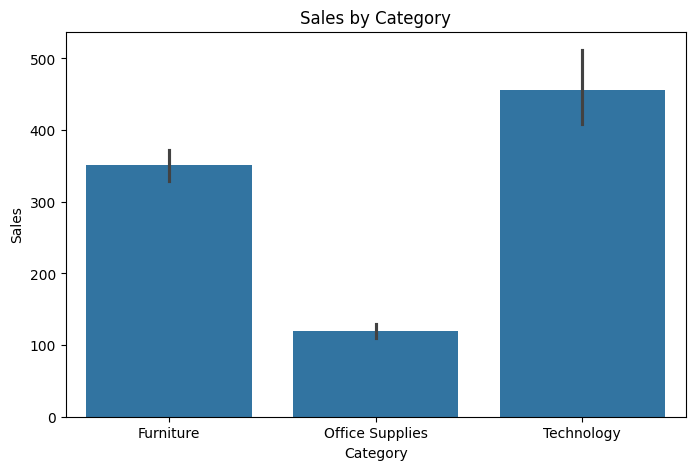

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

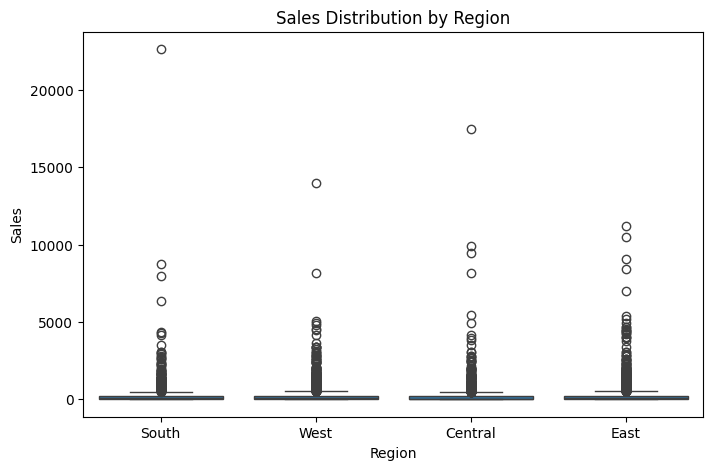

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region', y='Sales', data=df)
plt.title("Sales Distribution by Region")
plt.show()

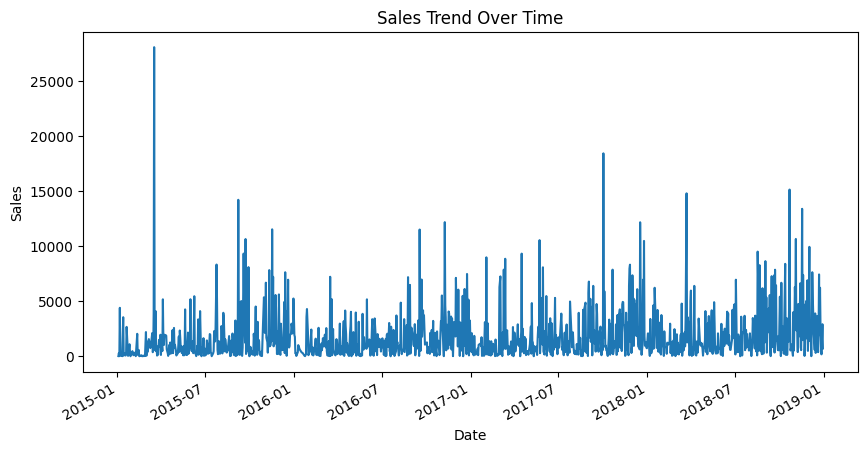

In [42]:
sales_trend = df.groupby('Order Date')['Sales'].sum()

plt.figure(figsize=(10,5))
sales_trend.plot()
plt.title("Sales Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

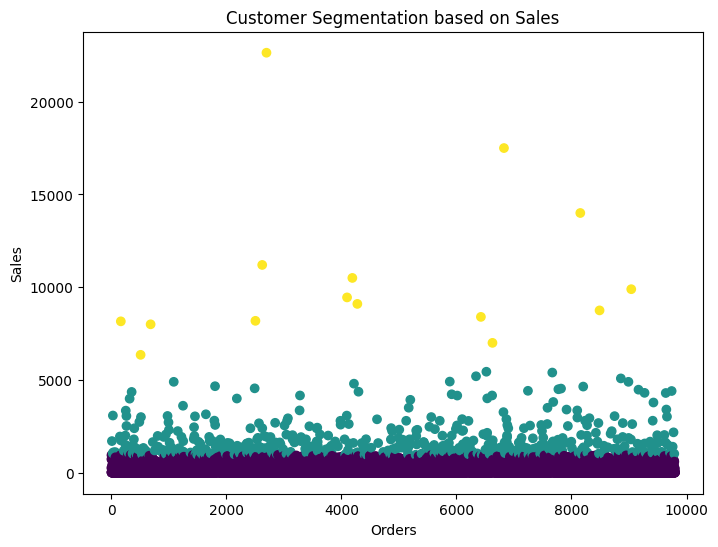

In [43]:
X = df[['Sales']]

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

df['Segment_Group'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(df.index, df['Sales'], c=df['Segment_Group'], cmap='viridis')
plt.xlabel("Orders")
plt.ylabel("Sales")
plt.title("Customer Segmentation based on Sales")
plt.show()

In [44]:
sales_series = df.groupby('Order Date')['Sales'].sum()

model = ARIMA(sales_series, order=(5,1,0))

model_fit = model.fit()

forecast = model_fit.forecast(steps=30)

print("Next 30 Days Forecast:")
print(forecast)

C:\Users\VEENA\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\VEENA\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\VEENA\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\VEENA\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given wit

Next 30 Days Forecast:
1230    1571.558330
1231    1244.492397
1232    1337.591731
1233    1528.660046
1234    1635.598395
1235    1326.253852
1236    1448.674948
1237    1404.129386
1238    1441.738745
1239    1461.374373
1240    1465.922395
1241    1422.344236
1242    1440.999554
1243    1436.239886
1244    1444.470585
1245    1445.417692
1246    1444.513231
1247    1438.483891
1248    1441.560608
1249    1441.239674
1250    1442.680067
1251    1442.433860
1252    1442.094744
1253    1441.299391
1254    1441.838829
1255    1441.850530
1256    1442.064995
1257    1441.959444
1258    1441.886808
1259    1441.791452
Name: predicted_mean, dtype: float64


Key Business Insights

1️⃣ Sales Trend

Sales fluctuate across different dates indicating varying demand over time.

2️⃣ Category Performance

Some product categories generate significantly higher sales than others.

3️⃣ Regional Sales

Certain regions contribute more to overall revenue compared to others.

4️⃣ Customer Segmentation

KMeans clustering divides orders into three sales groups:

High sales customers

Medium sales customers

Low sales customers

5️⃣ Forecasting

ARIMA forecasting predicts future sales trends which can help businesses plan inventory and marketing strategies.